# Exploring Clusters

This notebook explores the clusters that were formed by the K-Means Clustering in the notebook `module_1_clustering.ipynb`. Specifically, the goal is to determine the structure of the clusters across the real-estate, social and commercial dimension. 

## Load packages and Data

In [164]:
#load packages
import pandas as pd 
import numpy as np
from sklearn.impute import KNNImputer
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer
import seaborn as sns

In [165]:
#load dataframes 
clusters = pd.read_csv("../../data/Module_1/cluster_assignments.csv", dtype={"plr_id": str})
features = pd.read_csv("../../data/final_datasets/dataset_0.csv", dtype={"plr_id": str})
ms = pd.read_csv("../../data/Module 2/target_milieuschutz.csv", dtype={"plr_id": str})

#define id columns and feature columns
id_cols = ["plr_id", "plr_name", "bez"]
feat_cols = [c for c in features.columns if c not in id_cols]

features.head(2)
print(features.shape)

(527, 45)


In [166]:
#merge clusters 
df_merge1 = features.merge(clusters, on="plr_id", how="left")
#check 
print(df_merge1.shape)

(527, 47)


In [167]:
#merge milieuschutz areas 
df = df_merge1.merge(ms, on = ['plr_id', 'plr_name', 'bez'], how = "left")
print(df.shape)
df.head(2)

(527, 49)


,plr_id,plr_name,bez,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,...,com_gastro_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,re_altbau_share,re_neubau_share,cluster_3k,cluster_4k,milieu_anteil,milieu_majoritaet
0,01100101,Stülerstraße,01 - Mitte,22.7,2.142,3.050847,3890.584913,-0.326098,10.653753,0.460,...,0.003153,-0.00280,0.001395,13.000000,0.118160,0.102663,2,1,0.0,0
1,01100102,Großer Tiergarten,01 - Mitte,20.3,1.059,4.557180,3440.019389,-0.426678,24.075666,0.479,...,0.004856,-0.00093,-0.000664,129.333333,0.228719,0.297506,2,1,0.0,0


In [168]:
#rename columns from german > english (ms = milieuschutz: protected area under § 172 BGB)
df.rename(columns={"milieu_anteil": "ms_portion", "milieu_majoritaet": "ms_over50"}, inplace = True)
df.head()

,plr_id,plr_name,bez,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,...,com_gastro_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,re_altbau_share,re_neubau_share,cluster_3k,cluster_4k,ms_portion,ms_over50
0,01100101,Stülerstraße,01 - Mitte,22.70,2.142,3.050847,3890.584913,-0.326098,10.653753,0.460,...,0.003153,-0.002800,0.001395,13.000000,0.118160,0.102663,2,1,0.000000e+00,0
1,01100102,Großer Tiergarten,01 - Mitte,20.30,1.059,4.557180,3440.019389,-0.426678,24.075666,0.479,...,0.004856,-0.000930,-0.000664,129.333333,0.228719,0.297506,2,1,0.000000e+00,0
2,01100103,Lützowstraße,01 - Mitte,23.00,1.356,1.863997,3541.826020,-0.440097,16.223680,0.455,...,0.000177,-0.001019,0.000103,43.833333,0.323783,0.130135,2,1,7.967912e-01,1
3,01100104,Körnerstraße,01 - Mitte,26.21,2.276,1.721377,3499.906289,-0.451978,24.819856,0.507,...,0.001706,0.000616,-0.008733,31.833333,0.277822,0.189752,2,1,8.400603e-01,1
4,01100205,Wilhelmstraße,01 - Mitte,26.08,1.583,4.478708,9000.000000,-0.287682,24.963289,0.493,...,0.002437,-0.001641,0.001402,109.833333,0.168869,0.254038,2,1,2.602949e-08,0


In [169]:
#add columns for ms_over60, ms_over70, ms_over80, ms_over90
df["ms_over60"] = (df["ms_portion"] > 0.6).astype(int)
df["ms_over70"] = (df["ms_portion"] > 0.7).astype(int)
df["ms_over80"] = (df["ms_portion"] > 0.8).astype(int)
df["ms_over90"] = (df["ms_portion"] > 0.9).astype(int)
df.sample(5)

,plr_id,plr_name,bez,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,...,re_altbau_share,re_neubau_share,cluster_3k,cluster_4k,ms_portion,ms_over50,ms_over60,ms_over70,ms_over80,ms_over90
281,07100204,Barbarossaplatz,07 - Tempelhof-Schöneberg,27.50,3.694,1.178975,3800.000000,-0.169076,7.041100,0.416,...,0.436221,0.036679,2,1,0.763266,1,1,1,0,0
96,03300412,Karow Bahnhof,03 - Pankow,13.00,0.518,1.429190,500.000000,0.020203,3.464703,0.249,...,0.053270,0.218709,0,0,0.000000,0,0,0,0,0
13,01100414,Nordbahnhof,01 - Mitte,20.62,1.031,4.146839,4497.872168,-0.287698,15.975527,0.583,...,0.242692,0.548946,2,1,0.000000,0,0,0,0,0
165,04400727,Flinsberger Platz,04 - Charlottenburg-Wilmersdorf,18.75,1.114,2.197577,1918.487768,-0.365249,8.215239,0.354,...,0.133087,0.036558,2,1,0.000000,0,0,0,0,0
69,02400521,Friedenstraße,02 - Friedrichshain-Kreuzberg,25.93,3.185,1.771654,2405.740114,-0.486499,14.873141,0.494,...,0.199475,0.110455,2,1,0.000903,0,0,0,0,0


In [170]:
#sanity check
cols = ["ms_over60", "ms_over70", "ms_over80", "ms_over90"]
different = df[df[cols].nunique(axis=1) > 1]
different.sample(10)

,plr_id,plr_name,bez,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,...,re_altbau_share,re_neubau_share,cluster_3k,cluster_4k,ms_portion,ms_over50,ms_over60,ms_over70,ms_over80,ms_over90
70,02400522,Richard-Sorge-Viertel,02 - Friedrichshain-Kreuzberg,16.82,0.583,1.309977,3290.919622,-0.409119,13.709063,0.496,...,0.410815,0.083930,2,3,0.658841,1,1,0,0,0
302,07400825,Friedrich-Karl-Straße,07 - Tempelhof-Schöneberg,17.75,1.583,1.083293,1287.610723,-0.391463,8.666346,0.447,...,0.496389,0.013000,2,3,0.769441,1,1,1,0,0
44,01401045,Schwedenstraße,01 - Mitte,14.25,1.428,1.478953,1695.830577,-0.387057,9.859689,0.504,...,0.442928,0.078119,2,3,0.776353,1,1,1,0,0
301,07400824,Bosepark,07 - Tempelhof-Schöneberg,16.13,1.570,1.447402,1400.000000,-0.356675,8.787800,0.406,...,0.427759,0.019126,2,3,0.827547,1,1,1,1,0
340,08100415,Ganghoferstraße,08 - Neukölln,18.51,1.402,2.474657,2200.000000,-0.492476,13.714967,0.534,...,0.710793,0.012522,2,3,0.856740,1,1,1,1,0
47,01401048,Leopoldplatz,01 - Mitte,17.01,1.597,2.203526,1595.353026,-0.421565,5.608974,0.560,...,0.637220,0.013822,2,3,0.698003,1,1,0,0,0
284,07200307,Bayerischer Platz,07 - Tempelhof-Schöneberg,17.02,1.143,1.419096,3965.919971,-0.397544,5.090236,0.377,...,0.327318,0.018510,2,3,0.892220,1,1,1,1,0
288,07200411,Julius-Leber-Brücke,07 - Tempelhof-Schöneberg,12.15,0.444,0.652647,2959.625069,-0.371231,18.854242,0.423,...,0.857868,0.025381,2,3,0.714219,1,1,1,0,0
108,03400827,Trelleborger Viertel,03 - Pankow,18.01,1.760,1.761216,1374.816324,-0.385286,8.342603,0.424,...,0.322210,0.083055,2,3,0.695235,1,1,0,0,0
62,02300314,Oranienplatz,02 - Friedrichshain-Kreuzberg,14.04,2.204,1.278843,3001.319522,-0.484661,23.908813,0.400,...,0.717820,0.004726,2,3,0.743372,1,1,1,0,0


In [171]:
#save 
df.to_csv("../../data/final_datasets/df_clusters_milieuschutz.csv", index=False)
df.head(2)

,plr_id,plr_name,bez,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,...,re_altbau_share,re_neubau_share,cluster_3k,cluster_4k,ms_portion,ms_over50,ms_over60,ms_over70,ms_over80,ms_over90
0,01100101,Stülerstraße,01 - Mitte,22.7,2.142,3.050847,3890.584913,-0.326098,10.653753,0.460,...,0.118160,0.102663,2,1,0.0,0,0,0,0,0
1,01100102,Großer Tiergarten,01 - Mitte,20.3,1.059,4.557180,3440.019389,-0.426678,24.075666,0.479,...,0.228719,0.297506,2,1,0.0,0,0,0,0,0


## Gentrification Profiles

### Map

To get an overview of the geographic spread of the clusters across Berlin, let's look at them on a map.

In [172]:
url = ("https://gdi.berlin.de/services/wfs/lor_2021?service=WFS&version=2.0.0"
       "&request=GetFeature&typeNames=lor_2021:a_lor_plr_2021&outputFormat=application/json")
plr_geo = gpd.read_file(url)

# get plr-id's to strings with len 8
plr_geo["plr_id"] = plr_geo["plr_id"].astype(str).str.zfill(8)
df["plr_id_str"] = df["plr_id"].astype(str).str.zfill(8)

gdf = plr_geo.merge(df[["plr_id_str", "cluster_4k"]],
                    left_on="plr_id", right_on="plr_id_str", how="left")
print("matched:", gdf["cluster_4k"].notna().sum(), "von", len(gdf))

matched: 527 von 542


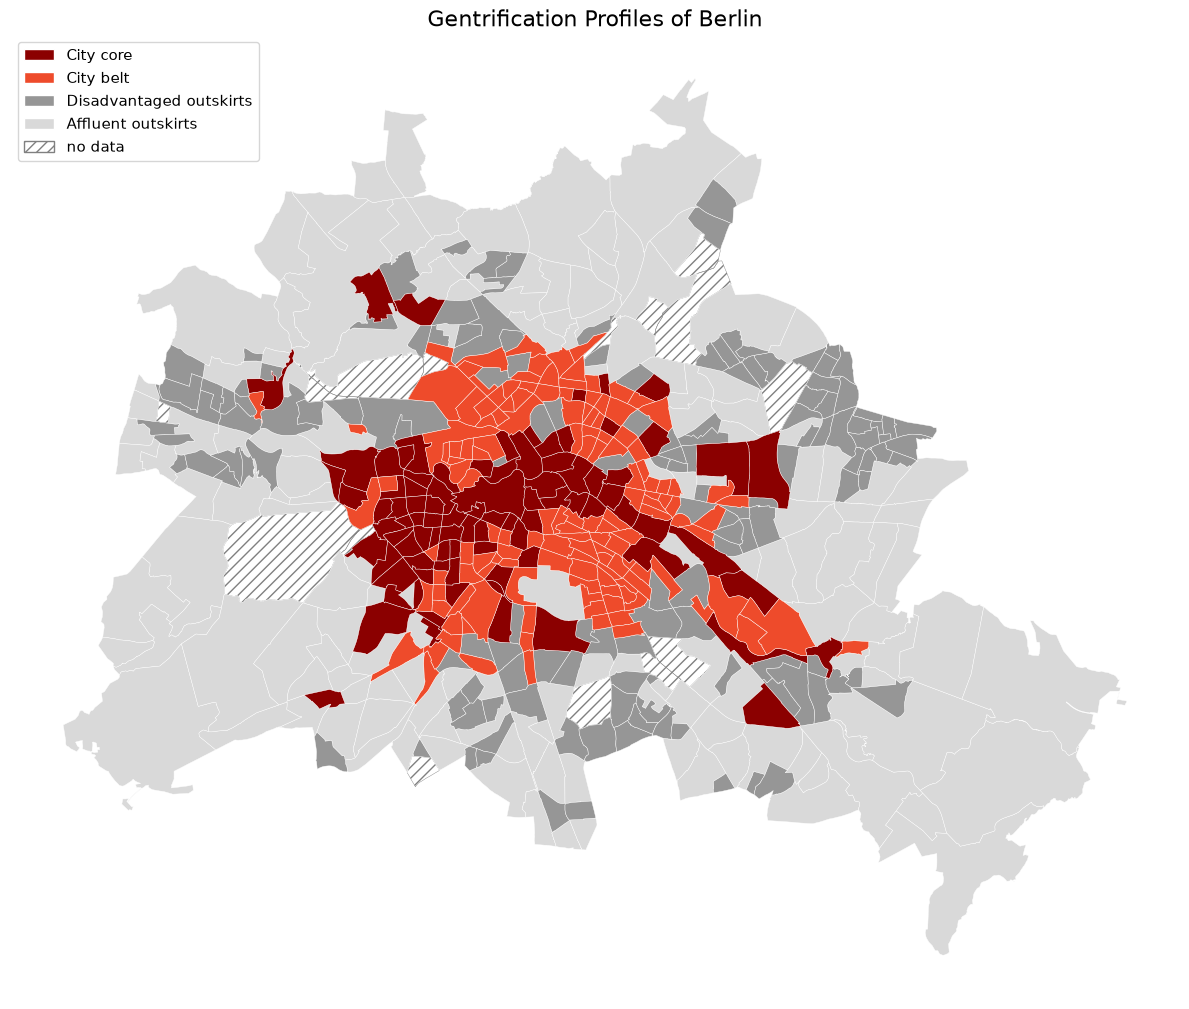

In [173]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(12, 12))
k = 4

cluster_colors = {
    3: "#EE4B2B",   # City belt — bright red 
    1: "#8B0000",   # City core — dark red 
    2: "#969696",   # Disadvantaged outskirts — mittelgrau
    0: "#d9d9d9",   # Affluent outskirts — helleres grau
}
cluster_labels = {
    1: "City core",
    3: "City belt",
    2: "Disadvantaged outskirts",
    0: "Affluent outskirts",
}

gdf[gdf["cluster_4k"].isna()].plot(
    ax=ax, color="none", edgecolor="grey", hatch="///", linewidth=0.3)


# Kontext-Cluster zuerst, dann City ring zuletzt (liegt oben)
for c in [0, 2, 1, 3]:
    gdf[gdf["cluster_4k"] == c].plot(
        ax=ax, color=cluster_colors[c], edgecolor="white", linewidth=0.3)

handles = [Patch(facecolor=cluster_colors[c], edgecolor="white", label=cluster_labels[c])
           for c in [1, 3, 2, 0]]   # City ring zuerst in der Legende
handles.append(Patch(facecolor="none", edgecolor="grey", hatch="///", label="no data"))
ax.legend(handles=handles, loc="upper left", fontsize=11, frameon=True)

ax.set_title(f"Gentrification Profiles of Berlin", fontsize=16)
ax.axis("off"); plt.tight_layout(); 
fig.savefig("../../plots/gentrification_profiles/cluster_map.png", dpi=300, bbox_inches="tight")
plt.show()

In order to determine whether the clusters can actually be described as gentrification phases/profiles, we need to take a look at what separates them and what characterizes each cluster. 

### Trend vs. Level:

In [174]:
def is_dynamic(c):
    return any(t in c for t in ["_trend", "_slope", "_change"])

for label, cols in [("LEVEL", [c for c in feat_cols if not is_dynamic(c)]),
                    ("DYNAMIC", [c for c in feat_cols if is_dynamic(c)])]:
    print(f"\n{'='*60}\n{label}\n{'='*60}")
    print(df.groupby("cluster_4k")[cols].mean().T.round(2).to_string())


LEVEL
cluster_4k                                    0        1       2        3
re_miete_niveau                           14.00    20.23   10.76    16.43
re_leerstandsquote                         2.21     2.33    1.80     2.03
re_brw_niveau                            772.06  3338.03  678.28  2436.18
re_dichte_all                              3.21    13.05    1.12    12.13
soc_young_to_middle_adult_share_2025       0.30     0.43    0.38     0.47
soc_average_household_size_2024            1.96     1.72    1.82     1.67
soc_internal_migration_volume_rate_2025    0.14     0.19    0.14     0.17
soc_internal_net_migration_rate_2025       0.01     0.00    0.01    -0.01
soc_transfer_benefit_share_2024            0.06     0.08    0.14     0.12
soc_single_parent_household_share_2024     0.05     0.04    0.06     0.04
com_median_age_level_2026                  7.79     6.96    5.02     5.84
com_share_solo_level_2026                  0.68     0.59    0.80     0.74
com_share_10plus_level_2026    

### Dimensions within profiles

First, let's look at a few variables that seem interesting based on prior knowledge of the data. 

The four profiles reveal a clear gentrification gradient by state:

- **City core:** is defined by its real-estate and commercial strength: the highest land values, Airbnb density, gastronomy counts, and upscale business share, paired with small households, below-average benefit dependency, and an above-average share of young adults. This is the mature, high-value, already-upgraded inner city.
- **City ring:** shares the core's density and gastronomy but is distinguished by the highest share of pre-war buildings, the youngest business stock, the smallest households, and the largest share of young adults, alongside moderately higher benefit dependency. This is the actively transforming inner-city milieu — dense, characterful, young, and still socially mixed.
- **Disadvantaged outskirts** show the mirror image: the highest benefit dependency, low land values, and the youngest, least upscale commercial structure, with a below-average share of young adults. These are the socially strained peripheral estates.
- **Affluent outskirts:** marked by the largest households, the oldest and most established businesses, the lowest benefit dependency, and the smallest share of young adults — a settled, family-oriented residential type that is not undergoing gentrification.

Across all four profiles, the differentiation is driven almost entirely by level variables (current state) rather than dynamic ones, supporting an interpretation of the clusters as gentrification profiles — distinct area types at different stages of the process — rather than temporal phases.

46 Features


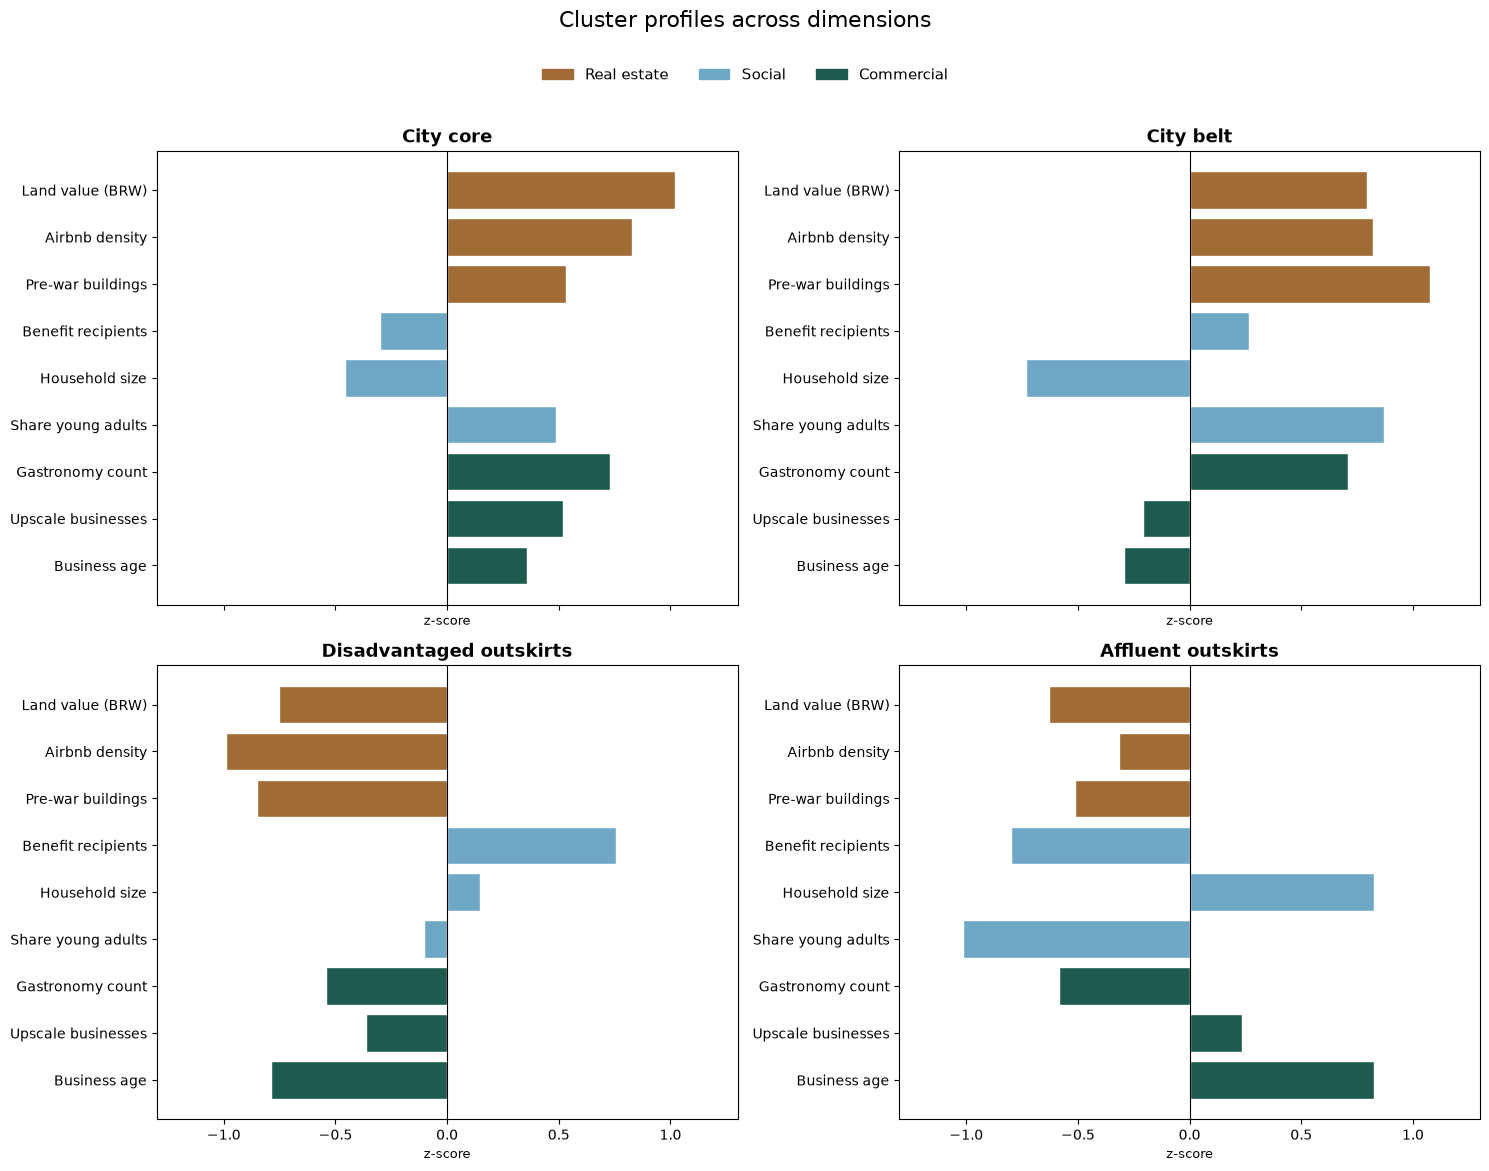

In [175]:
from matplotlib.patches import Patch
#prepare data
id_cols = ["plr_id", "plr_name", "bez"]
non_features = id_cols + ["cluster_3k", "cluster_4k", "ms_portion", "ms_over50", "plr_id_str"]
feat_cols = [c for c in df.columns if c not in non_features]
print(len(feat_cols), "Features") 

X = df[feat_cols]

X_scaled = pd.DataFrame(
    PowerTransformer("yeo-johnson", standardize=True).fit_transform(X),
    columns=feat_cols, index=X.index,
)


Xs = X_scaled.copy()
Xs["cluster_4k"] = df["cluster_4k"].values


chosen = ["re_brw_niveau", "re_dichte_all", "re_altbau_share", #land value, airbnb density, old building share
          "soc_transfer_benefit_share_2024", "soc_average_household_size_2024", "soc_young_to_middle_adult_share_2025", #transfer benefits, average household size, 
          "com_n_gastro", "com_upscale_share_level_2026", "com_median_age_level_2026"] #gastro establishments, upscale gastro, median age of businesses

axis_labels = {
    "re_brw_niveau": "Land value (BRW)",
    "re_dichte_all": "Airbnb density",
    "re_altbau_share": "Pre-war buildings",
    "soc_transfer_benefit_share_2024": "Benefit recipients",
    "soc_average_household_size_2024": "Household size",
    "soc_young_to_middle_adult_share_2025": "Share young adults",
    "com_n_gastro": "Gastronomy count",
    "com_upscale_share_level_2026": "Upscale businesses",
    "com_median_age_level_2026": "Business age",
}

# re_ = Gold, soc_ = Blau, com_ = Grün
dim_color = {"re_": "#A06B34", "soc_": "#6FA8C7", "com_": "#1D5B4E"}
bar_colors = [next(dim_color[p] for p in dim_color if v.startswith(p)) for v in chosen]

z = Xs.groupby("cluster_4k")[chosen].mean()

labels = {1: "City core", 3: "City belt",
          2: "Disadvantaged outskirts", 0: "Affluent outskirts"}
order = [1, 3, 2, 0]

fig, axes = plt.subplots(2, 2, figsize=(15, 11), sharex=True)
ypos = np.arange(len(chosen))
for ax, c in zip(axes.flat, order):
    ax.barh(ypos, z.loc[c, chosen].values, color=bar_colors, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_yticks(ypos); ax.set_yticklabels([axis_labels[v] for v in chosen], fontsize=10)
    ax.invert_yaxis()
    ax.set_title(labels[c], fontsize=13, fontweight="bold")
    ax.set_xlabel("z-score", fontsize=9); ax.set_xlim(-1.3, 1.3)

handles = [Patch(color="#A06B34", label="Real estate"),
           Patch(color="#6FA8C7", label="Social"),
           Patch(color="#1D5B4E", label="Commercial")]
fig.legend(handles=handles, loc="upper center", ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, 1.02), frameon=False)
fig.suptitle("Cluster profiles across dimensions", fontsize=16, y=1.06)
plt.tight_layout()
fig.savefig("../../plots/gentrification_profiles/cluster_profiles.png", dpi=300, bbox_inches="tight")
plt.show()

### Most discriminating variables:

So far, the variable selection has been interest-driven. Let's look at a data-driven selection of variables that seperate the clusters.

In [176]:
# show the 20 most discriminating variables 
means_by_cluster = Xs.groupby("cluster_4k")[feat_cols].apply(
    lambda g: g.mean())   

Xs = X_scaled.copy(); Xs["cluster_4k"] = df["cluster_4k"].values
spread = Xs.groupby("cluster_4k")[feat_cols].mean().var().sort_values(ascending=False)
print(spread.head(20))

re_brw_niveau                                  0.865307
re_miete_niveau                                0.805934
re_altbau_share                                0.805855
re_dichte_all                                  0.805692
soc_young_to_middle_adult_share_2025           0.671929
com_share_solo_level_2026                      0.652160
re_brw_trend                                   0.606369
com_n_gastro                                   0.550424
soc_single_parent_household_share_2024         0.541097
com_exit_rate_level_2026                       0.515219
com_median_age_level_2026                      0.504414
soc_average_household_size_2024                0.479698
soc_transfer_benefit_share_2024                0.454840
ms_over60                                      0.423925
com_entry_rate_level_2026                      0.375490
com_tourism_share_level_2026                   0.338258
ms_over70                                      0.334389
soc_internal_migration_volume_rate_2025        0

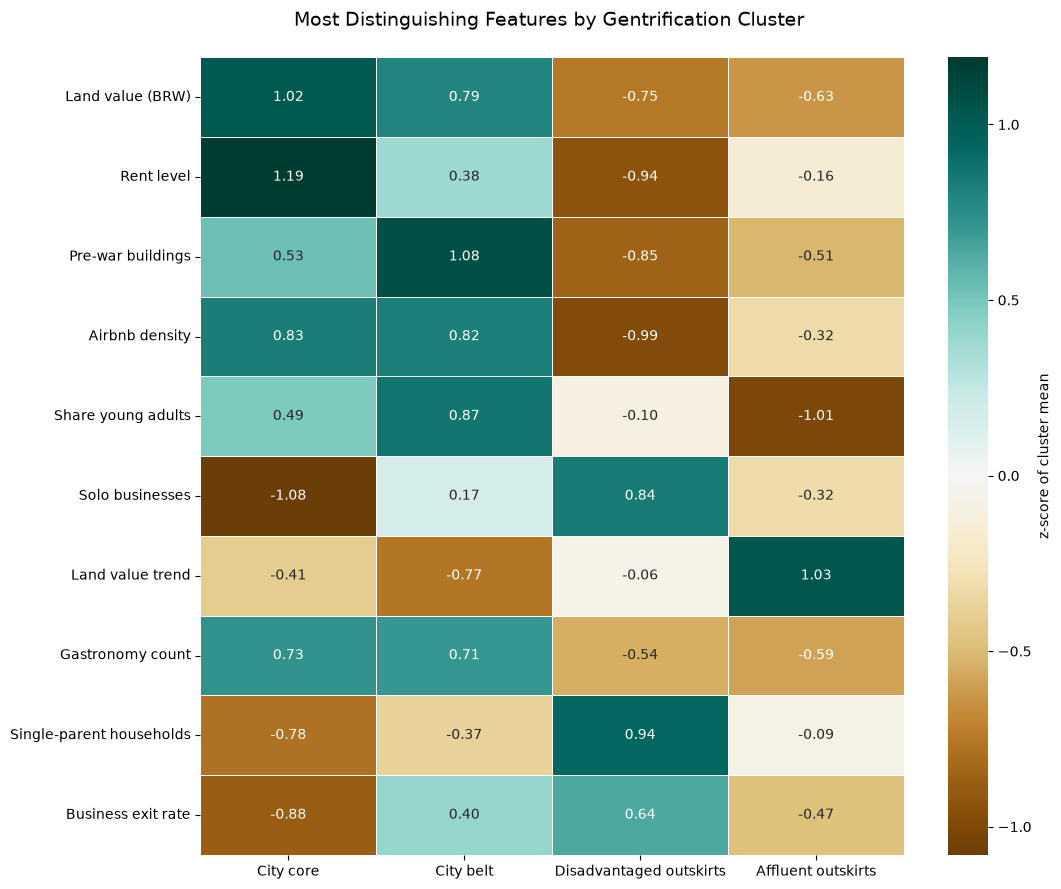

In [177]:
# Top 10 (based on spread: largest variance between cluster means)
spread = Xs.groupby("cluster_4k")[feat_cols].mean().var().sort_values(ascending=False)
chosen = spread.head(10).index.tolist()

axis_labels = {
    "re_brw_niveau": "Land value (BRW)",
    "re_miete_niveau": "Rent level",
    "re_dichte_all": "Airbnb density",
    "re_altbau_share": "Pre-war buildings",
    "re_neubau_share": "New-build share",
    "re_brw_trend": "Land value trend",
    "re_miete_trend": "Rent trend",
    "soc_young_to_middle_adult_share_2025": "Share young adults",
    "soc_single_person_hh_share_2024": "Single-person households",
    "soc_single_parent_household_share_2024": "Single-parent households",
    "soc_average_household_size_2024": "Household size",
    "soc_transfer_benefit_share_2024": "Benefit recipients",
    "com_share_solo_level_2026": "Solo businesses",
    "com_exit_rate_level_2026": "Business exit rate",
    "com_entry_rate_level_2026": "Business entry rate",
    "com_n_gastro": "Gastronomy count",
    "com_upscale_share_level_2026": "Upscale Gastronomy",
    "com_median_age_level_2026": "Business age",
}

labels = {1:"City core", 3:"City belt", 2:"Disadvantaged outskirts", 0:"Affluent outskirts"}
order = [1, 3, 2, 0]

zt = Xs.groupby("cluster_4k")[chosen].mean().reindex(order).T
zt.columns = [labels[c] for c in order]
zt.index = [axis_labels.get(v, v) for v in chosen]      # <- lesbare Labels

plt.figure(figsize=(11, 9))
sns.heatmap(zt, cmap="BrBG", center=0, annot=True, fmt=".2f",
            linewidths=0.5, cbar_kws={"label": "z-score of cluster mean"})
plt.title("Most Distinguishing Features by Gentrification Cluster \n", fontsize = 14)
plt.tight_layout(); 
fig.savefig("../../plots/gentrification_profiles/distinguishing_features.png", dpi=300, bbox_inches="tight")
plt.show()

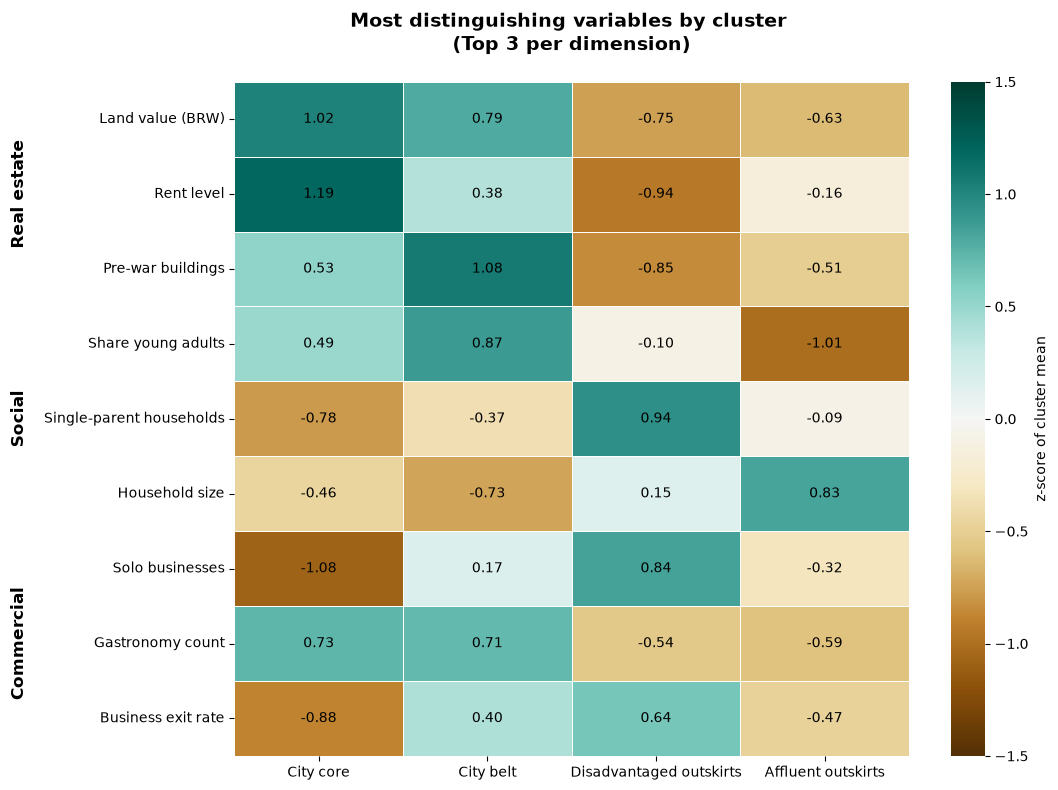

In [178]:
import seaborn as sns, matplotlib.pyplot as plt

spread = Xs.groupby("cluster_4k")[feat_cols].mean().var()
chosen = []
for pre in ["re_", "soc_", "com_"]:
    dim = spread[[c for c in feat_cols if c.startswith(pre)]].sort_values(ascending=False)
    chosen += dim.head(3).index.tolist()

axis_labels = {
    "re_brw_niveau":"Land value (BRW)", "re_dichte_all":"Airbnb density",
    "re_miete_niveau":"Rent level", "re_altbau_share":"Pre-war buildings",
    "soc_single_person_hh_share_2024":"Single-person households",
    "soc_young_to_middle_adult_share_2025":"Share young adults",
    "soc_single_parent_household_share_2024":"Single-parent households",
    "soc_average_household_size_2024":"Household size",
    "com_share_solo_level_2026":"Solo businesses",
    "com_exit_rate_level_2026":"Business exit rate", "com_n_gastro":"Gastronomy count",
}
labels = {1:"City core", 3:"City belt", 2:"Disadvantaged outskirts", 0:"Affluent outskirts"}
order = [1, 3, 2, 0]

zt = Xs.groupby("cluster_4k")[chosen].mean().reindex(order).T
zt.columns = [labels[c] for c in order]
zt.index = [axis_labels.get(v, v) for v in chosen]

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(zt, cmap="BrBG", center=0, annot=True, fmt=".2f",
            vmin=-1.5, vmax=1.5, linewidths=0.5, linecolor="white",
            annot_kws={"color":"black","fontsize":10},
            cbar_kws={"label":"z-score of cluster mean"}, ax=ax)


# Dimensionsnamen links neben den Blöcken (Blockmitte: 1.5, 4.5, 7.5)
dim_names = [("Real estate", 1.5), ("Social", 4.5), ("Commercial", 7.5)]
for name, ypos in dim_names:
    ax.text(-0.32, ypos, name, transform=ax.get_yaxis_transform(),
            rotation=90, va="center", ha="center",
            fontsize=12, fontweight="bold")

plt.title("Most distinguishing variables by cluster \n(Top 3 per dimension)\n", fontsize = 14, fontweight="bold")
plt.tight_layout(); 
fig.savefig("../../plots/gentrification_profiles/distinguishing_features_perdim.png", dpi=300, bbox_inches="tight")
plt.show()

## Milieuschutz areas

The next step is to compare the clusters against already protected areas to identify the gaps. 

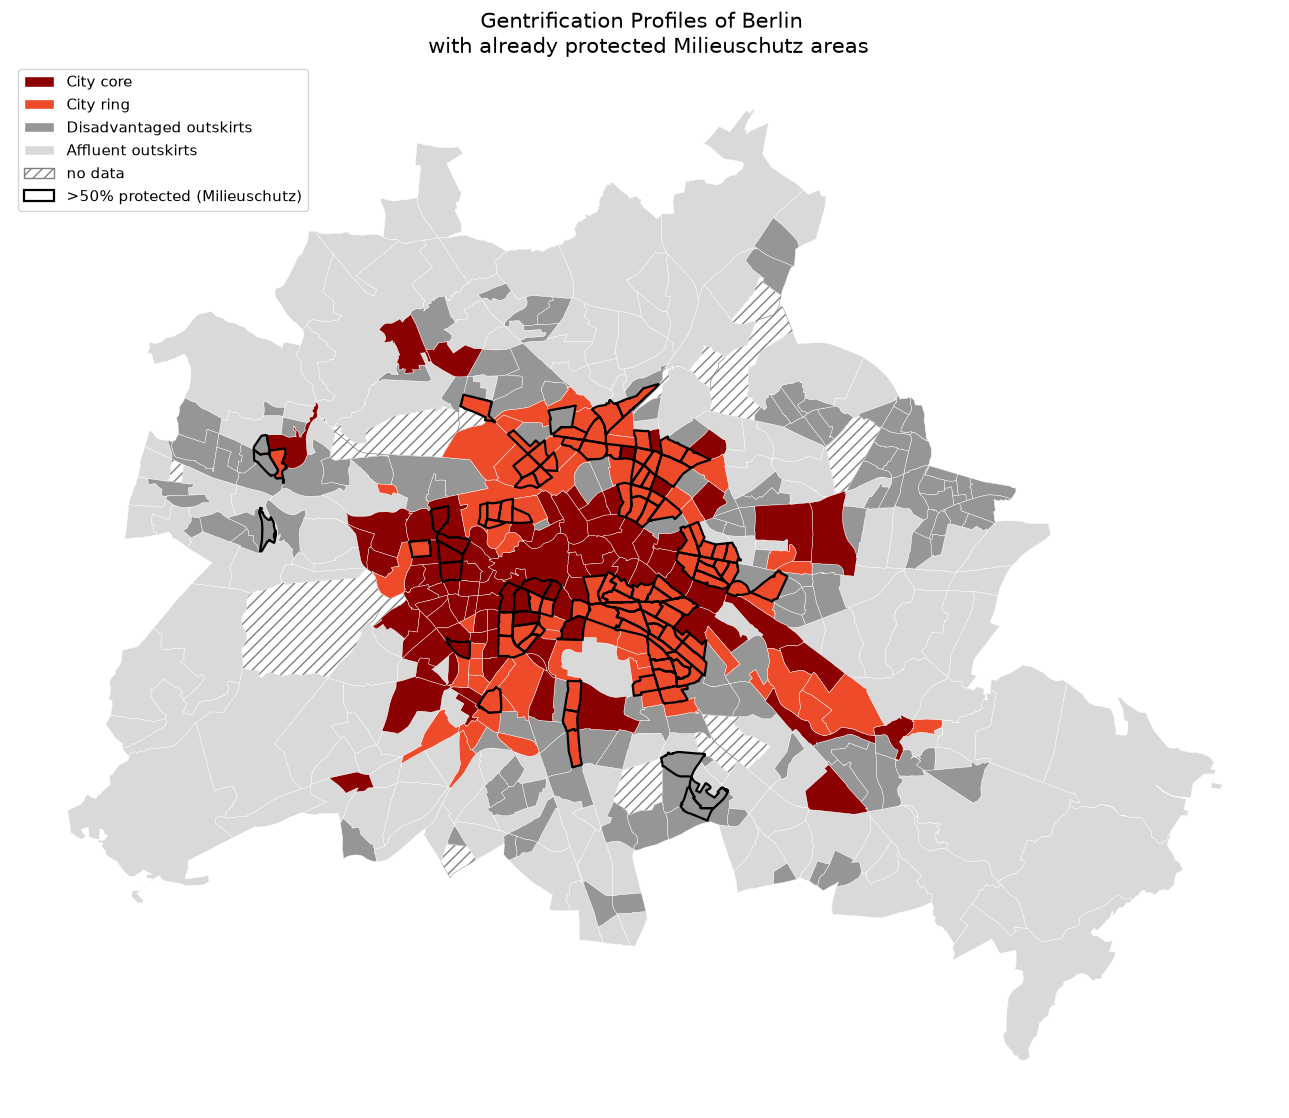

In [179]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 
df["plr_id_str"] = df["plr_id"].astype(str).str.zfill(8)
gdf = plr_geo.merge(
    df[["plr_id_str", "cluster_4k", "ms_over50", "ms_portion"]],
    left_on="plr_id", right_on="plr_id_str", how="left")

fig, ax = plt.subplots(figsize=(13, 13))

cluster_colors = {
    3: "#EE4B2B",   # City belt — bright red 
    1: "#8B0000",   # City core — dark red 
    2: "#969696",   # Disadvantaged outskirts — mittelgrau
    0: "#d9d9d9",   # Affluent outskirts — helleres grau
}
cluster_labels = {1: "City core", 3: "City ring",
                  2: "Disadvantaged outskirts", 0: "Affluent outskirts"}

# Clusterings
gdf[gdf["cluster_4k"].isna()].plot(ax=ax, color="none", edgecolor="grey",
                                    hatch="///", linewidth=0.3)
for c in [0, 2, 1, 3]:
    gdf[gdf["cluster_4k"] == c].plot(ax=ax, color=cluster_colors[c],
                                      edgecolor="white", linewidth=0.3)

# MS-areas
ms = gdf[gdf["ms_over50"] == 1]
ms.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.6)

# Legend
handles = [Patch(facecolor=cluster_colors[c], edgecolor="white", label=cluster_labels[c])
           for c in [1, 3, 2, 0]]
handles.append(Patch(facecolor="none", edgecolor="grey", hatch="///", label="no data"))
handles.append(Patch(facecolor="none", edgecolor="black", linewidth=1.6, label=">50% protected (Milieuschutz)"))
ax.legend(handles=handles, loc="upper left", fontsize=11, frameon=True)

ax.set_title("Gentrification Profiles of Berlin \n with already protected Milieuschutz areas", fontsize=15)
ax.axis("off"); plt.tight_layout();
fig.savefig("../../plots/gentrification_profiles/cluster_milieuschutz_over50_map.png", dpi=300, bbox_inches="tight")
plt.show()

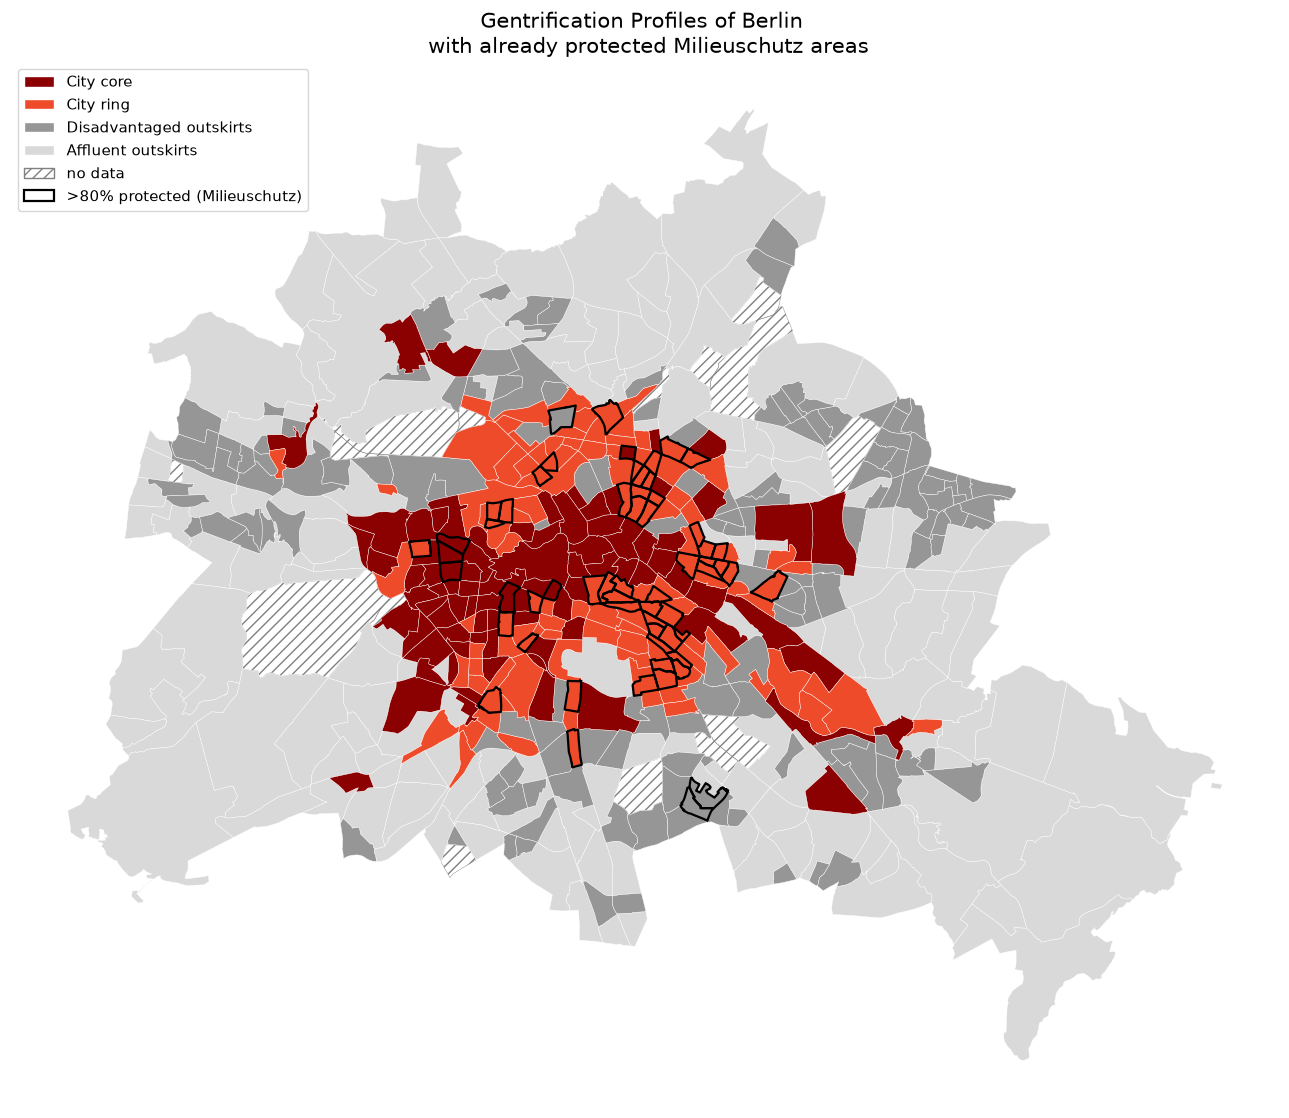

In [180]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 
df["plr_id_str"] = df["plr_id"].astype(str).str.zfill(8)
gdf = plr_geo.merge(
    df[["plr_id_str", "cluster_4k", "ms_over80", "ms_portion"]],
    left_on="plr_id", right_on="plr_id_str", how="left")

fig, ax = plt.subplots(figsize=(13, 13))

cluster_colors = {
    3: "#EE4B2B",   # City belt — bright red 
    1: "#8B0000",   # City core — dark red 
    2: "#969696",   # Disadvantaged outskirts — mittelgrau
    0: "#d9d9d9",   # Affluent outskirts — helleres grau
}
cluster_labels = {1: "City core", 3: "City ring",
                  2: "Disadvantaged outskirts", 0: "Affluent outskirts"}

# Clusterings
gdf[gdf["cluster_4k"].isna()].plot(ax=ax, color="none", edgecolor="grey",
                                    hatch="///", linewidth=0.3)
for c in [0, 2, 1, 3]:
    gdf[gdf["cluster_4k"] == c].plot(ax=ax, color=cluster_colors[c],
                                      edgecolor="white", linewidth=0.3)

# MS-areas
ms = gdf[gdf["ms_over80"] == 1]
ms.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.6)

# Legend
handles = [Patch(facecolor=cluster_colors[c], edgecolor="white", label=cluster_labels[c])
           for c in [1, 3, 2, 0]]
handles.append(Patch(facecolor="none", edgecolor="grey", hatch="///", label="no data"))
handles.append(Patch(facecolor="none", edgecolor="black", linewidth=1.6, label=">80% protected (Milieuschutz)"))
ax.legend(handles=handles, loc="upper left", fontsize=11, frameon=True)

ax.set_title("Gentrification Profiles of Berlin \n with already protected Milieuschutz areas", fontsize=15)
ax.axis("off"); plt.tight_layout(); 
fig.savefig("../../plots/gentrification_profiles/cluster_milieuschutz_over80_map.png", dpi=300, bbox_inches="tight")
plt.show()

The Milieuschutz areas cluster clearly on the red City ring and, to a lesser extent, the dark-grey City core — the dense, upgrading inner city where the analysis locates the strongest gentrification pressure. This spatial correspondence between a data-driven typology and an independent policy instrument lends external validity to the clustering: the areas the state has designated as at-risk of displacement largely coincide with those the profile identifies as actively transforming. At the same time, several red City-ring PLRs lie outside any Milieuschutz outline, marking upgrading neighbourhoods not yet covered by the statute — potential protection gaps and, in classification terms, candidate areas for the subsequent analysis.

In [181]:
df["plr_id_str"] = df["plr_id"].astype(str).str.zfill(8)
gdf = plr_geo.merge(
    df[["plr_id_str", "cluster_4k", "ms_over50", "ms_portion"]],
    left_on="plr_id", right_on="plr_id_str", how="left")

# Share of protected areas per Cluster
overlap = (gdf.groupby("cluster_4k")["ms_over50"]
           .agg(["mean", "sum", "count"])
           .rename(columns={"mean": "share_protected",
                            "sum": "n_protected", "count": "n_total"})
           .reindex([1, 3, 2, 0]))          #set order from inner circle to outskirts

overlap.index = overlap.index.map({1:"City core", 3:"City ring",
                                   2:"Disadvantaged outskirts", 0:"Affluent outskirts"})
print(overlap.round(2))

                         share_protected  n_protected  n_total
cluster_4k                                                    
City core                           0.13         12.0       90
City ring                           0.63         90.0      142
Disadvantaged outskirts             0.05          7.0      145
Affluent outskirts                  0.00          0.0      150


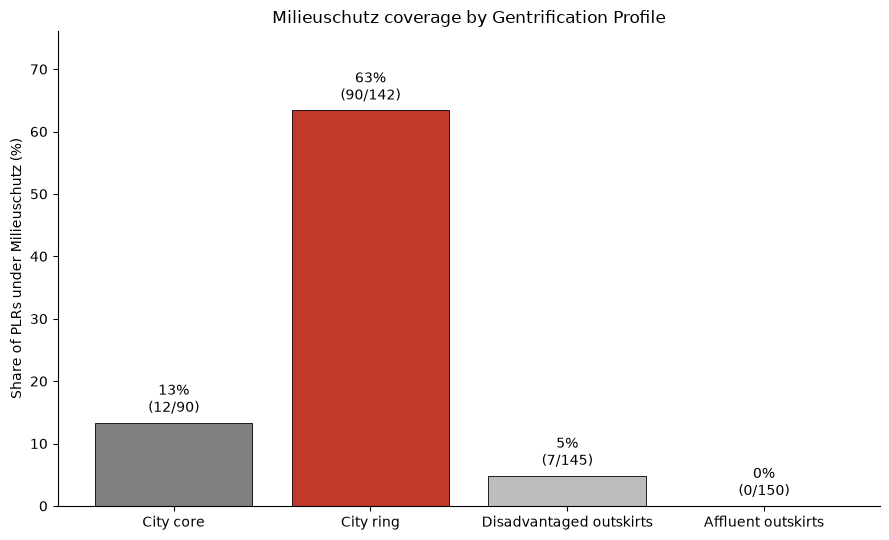

In [182]:
import matplotlib.pyplot as plt

# Share of protected PLRs 
overlap = (gdf.groupby("cluster_4k")["ms_over50"]
           .agg(["mean", "sum", "count"])
           .rename(columns={"mean":"share_protected","sum":"n_protected","count":"n_total"})
           .reindex([1, 3, 2, 0]))

cluster_labels = {1:"City core", 3:"City ring",
                  2:"Disadvantaged outskirts", 0:"Affluent outskirts"}
cluster_colors = {1:"#7f7f7f", 3:"#c0392b", 2:"#bdbdbd", 0:"#e0e0e0"}  # wie die Karte

order = [1, 3, 2, 0]
names  = [cluster_labels[c] for c in order]
shares = overlap["share_protected"].values * 100          # in Prozent
colors = [cluster_colors[c] for c in order]

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(names, shares, color=colors, edgecolor="black", linewidth=0.6)

# % on each bar
for bar, s, n, tot in zip(bars, shares, overlap["n_protected"], overlap["n_total"]):
    ax.text(bar.get_x() + bar.get_width()/2, s + 1,
            f"{s:.0f}%\n({int(n)}/{int(tot)})",
            ha="center", va="bottom", fontsize=10)

ax.set_ylabel("Share of PLRs under Milieuschutz (%)")
ax.set_title("Milieuschutz coverage by Gentrification Profile")
ax.set_ylim(0, max(shares) * 1.2)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout();
fig.savefig("../../plots/gentrification_profiles/cluster_milieuschutz_bar.png", dpi=300, bbox_inches="tight")
plt.show()

The majority of the city ring is already protected. What is going on in the PLRs that are not protected (yet)? Are they different from the ones that are protected?

In [183]:
cl3_unprotected = df.loc[(df['cluster_4k'] == 3) & (df['ms_over50'] == 0)]
cl3_protected = df.loc[(df['cluster_4k'] == 3) & (df['ms_over50'] == 1)]

# Vergleich: geschützte vs. ungeschützte City-ring-PLR
grp = df[df["cluster_4k"] == 3].groupby("ms_over50")[feat_cols].mean().T
grp.columns = ["unprotected", "protected"]
grp["diff (prot - unprot)"] = (grp["protected"] - grp["unprotected"])

# nach Dimension sortiert, größte Unterschiede zuerst innerhalb jeder
grp["absdiff"] = grp["diff (prot - unprot)"].abs()
print(f"City ring: {len(cl3_protected)} protected vs {len(cl3_unprotected)} unprotected\n")
print(grp.sort_values("absdiff", ascending=False).drop(columns="absdiff").round(3).to_string())

City ring: 90 protected vs 52 unprotected

                                                              unprotected  protected  diff (prot - unprot)
re_brw_niveau                                                    1889.327   2752.134               862.806
com_n_gastro                                                       33.407     60.652                27.245
re_dichte_all                                                       7.640     14.717                 7.076
ms_over60                                                           0.000      0.867                 0.867
ms_over70                                                           0.000      0.700                 0.700
re_miete_niveau                                                    16.067     16.640                 0.573
ms_over80                                                           0.000      0.567                 0.567
ms_over90                                                           0.000      0.333                 

## Add-on: Clusters based on change variables only

Earlier, it became clear that the trend variables did not contribute much to the clustering. This is an exploration whether clustering on the trend variables alone adds any value.

In [185]:
id_cols = ["plr_id", "plr_name", "bez"]
non_features = id_cols + ["cluster_3k", "cluster_4k", "ms_portion", "ms_over50", "plr_id_str","ms_over60","ms_over70","ms_over80","ms_over90"]
feat_cols = [c for c in df.columns if c not in non_features]
print(len(feat_cols), "Features") 

X = df[feat_cols]

# keep plr_id retrievable; work on a feature-only matrix
X = df[feat_cols].copy()
ids = df[id_cols].copy()

# 1) impute the 3 gaps (2 PLRs) from similar PLRs
X_imp = pd.DataFrame(
    KNNImputer(n_neighbors=3).fit_transform(X),
    columns=feat_cols, index=df.index,
)


X_scaled = pd.DataFrame(
    PowerTransformer("yeo-johnson", standardize=True).fit_transform(X_imp),
    columns=feat_cols, index=X_imp.index,
)

X_scaled.head(3)

42 Features


,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,soc_young_to_middle_adult_share_change_2021_2025,soc_single_person_hh_share_change_2021_2024,soc_average_household_size_2024,...,com_share_min_30y_slope,com_share_min_40y_slope,com_share_solo_slope,com_share_10plus_slope,com_gastro_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,re_altbau_share,re_neubau_share
0,1.707607,1.345248,1.062483,1.401119,-0.514159,0.938569,0.789265,-0.423212,-0.854709,-1.183481,...,-0.059062,-0.227172,1.531979,0.952109,0.959637,-1.143363,-0.728138,-0.314274,-0.225292,0.638800
1,1.219387,0.033646,1.781115,1.306092,-1.096115,1.599031,0.985896,-0.282827,-1.223596,-0.004727,...,0.407217,0.680906,1.898433,0.860206,1.724478,-0.424651,-1.854356,1.880504,0.381165,1.777773
2,1.767611,0.419433,0.074113,1.329091,-1.175228,1.284139,0.736851,0.555171,-0.191582,-0.444817,...,-0.021163,0.706418,2.197820,-0.451547,-0.201956,-0.461120,-1.439860,0.830252,0.755869,0.929094


21 change-Variablen


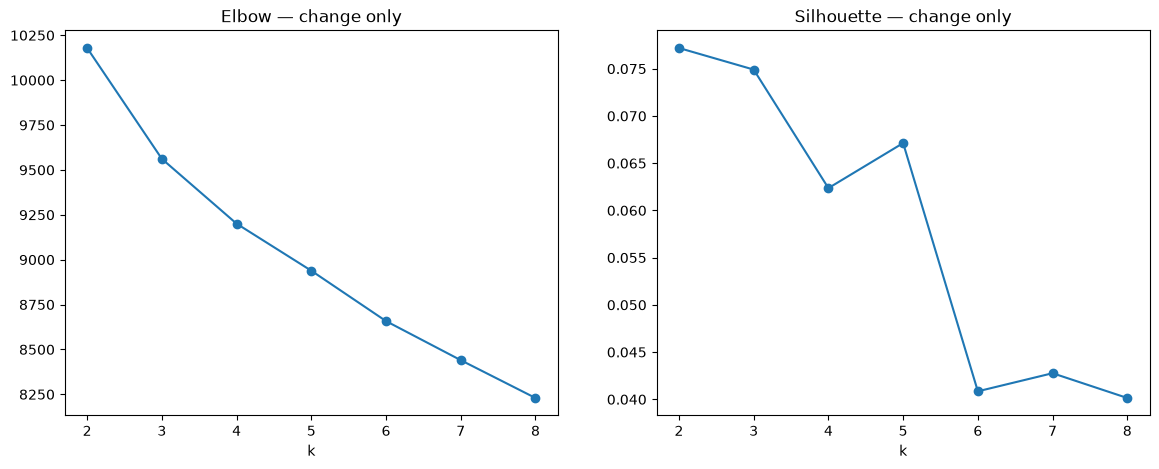

k=2: silhouette = 0.077
k=3: silhouette = 0.075
k=4: silhouette = 0.062
k=5: silhouette = 0.067
k=6: silhouette = 0.041
k=7: silhouette = 0.043
k=8: silhouette = 0.040


In [186]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

change_cols = [c for c in feat_cols if any(t in c for t in ["_trend","_slope","_change"])]
X_change = X_scaled[change_cols]     # schon standardisiert (Option A)
print(f"{len(change_cols)} change-Variablen")

# Elbow + Silhouette über k
Ks = range(2, 9)
wcss, sils = [], []
for k in Ks:
    km = KMeans(k, n_init=10, random_state=0).fit(X_change)
    wcss.append(km.inertia_)
    sils.append(silhouette_score(X_change, km.labels_))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14,5))
a1.plot(Ks, wcss, "o-"); a1.set_title("Elbow — change only"); a1.set_xlabel("k")
a2.plot(Ks, sils, "o-"); a2.set_title("Silhouette — change only"); a2.set_xlabel("k")
plt.show()

for k, s in zip(Ks, sils):
    print(f"k={k}: silhouette = {s:.3f}")

The silhouette scores are alarmingly low and the elbow plot almost looks like a straight line. Thus, even when clustering on the dynamic variables alone, the differences are not enough for a solid clustering base. 